# LMS for System Identification

This notebook covers the LMS algorithm applied to system identification — the foundational use case before ANC.

1. Background
2. LMS: Least Mean Squares
   - 2a. System Identification (sinusoid extraction from noise)

Feedforward ANC and NLMS are covered in `ANC_LMS_ANC_Demo.ipynb`. FxLMS and real-world applications are in a separate notebook.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Background
### Destructive Interference

Destructive interference occurs when two acoustic waveforms combine in such a way that their amplitudes partially or completely cancel. In the ideal case, complete cancellation occurs when one signal is the negative (phase-inverted) version of the other.

For a signal $x(t)$, we can define a cancelling signal:

$$x_{cancel}(t) = -x(t)$$

which yields:

$$y(t) = x(t) + x_{cancel}(t) = 0$$

For a sinusoidal signal, the cancelling signal corresponds to a phase shift of 180° (or π radians). Note that this cancellation principle applies to arbitrary signals, not just sinusoids.

In practice, generating a precise cancelling signal requires modeling a more complex acoustic propagation path through space. This is the primary challenge to address via adaptive filtering in ANC systems.

# Least Mean Square (LMS) Algorithm

The LMS algorithm is a simple and direct approach to estimating a given process $d[n]$ from a related process $x[n]$. It operates by iteratively updating the weights of vector **w** via the equation

**w**$_{n+1}$ = **w**$_n$ + $\mu e[n]$ __x__*$[n]$

where $\mu$ represents a predetermined learning rate.

The full algorithm then takes the form

For n = 0, 1, 2, ..., N-1: <br>
(a) $y[n]$ = **w**$_n^T$**x**$[n]$ <br>
(b) $e[n]$ = $d[n] - y[n]$ <br>
(c) **w**$_{n+1}$ = **w**$_n$ + $\mu e[n]$ __x__*$[n]$

(Note: __x__*$[n]$ indicates complex conjugate for consideration of complex signals. Not necessary for real-valued inputs)

Reference:<br>
[1] Monson H. Hayes, *Statistical Digital Signal Processing and Modeling*. New York, NY, USA: John Wiley & Sons, 1996. (pg. 506)

### 2a. LMS for System Identification

This section outlines the use of the LMS algorithm for system identification. The diagram below shows a system (Plant) with response $d[n]$ from a given input signal $x[n]$. The goal is to model a system **W**$_n[z]$ that computes an estimate $\widehat{d}[n]$ as close to $d[n]$ as possible. An additive noise source is included as $v[n]$ to account for observation noise in the measurement of the Plant's output. The error signal $e[n]$ is fed back into the adaptive filter to measure performance and optimize filter coefficients.

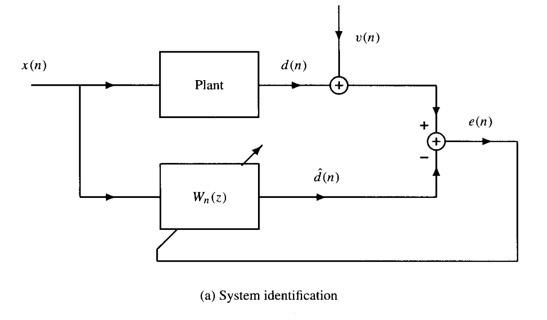

(Diagram: Hayes Fig. 9.14a — System Identification block diagram)

(Note: Hayes uses () in place of [] in the notation. Brackets are kept here to represent discrete indices.)

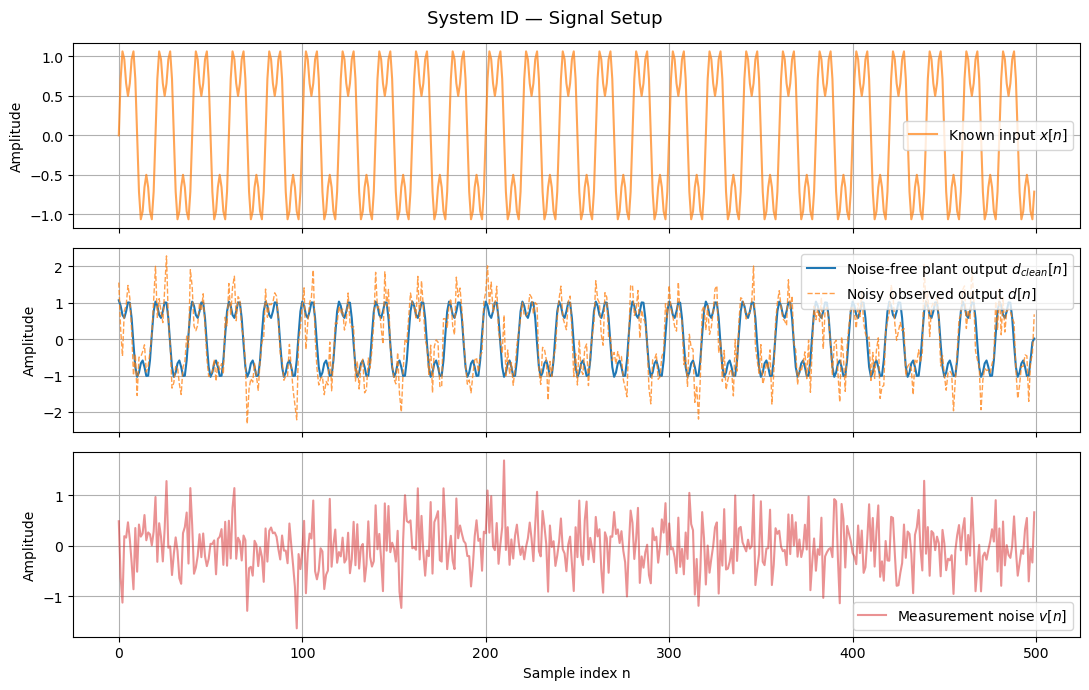

In [ ]:
# Signal Setup ->
# x[n]: known input to the unknown plant
# d[n]: observed plant output with measurement noise
N = 500
n = np.arange(N)

# Known input signal: 1Hz sine wave
x = np.sin(2 * np.pi * 0.05 * n) + 0.5 * np.sin(2 * np.pi * 0.15 * n)

# True unknown plant impulse response (for simulation)
h_true = np.array([0.3, 0.6, 0.2, -0.1, 0.05, 0.0, 0.0, 0.0])
M = len(h_true)

# Plant output d[n] = h_true * x[n] plus measurement noise
d_clean = np.convolve(x, h_true, mode="same")
v = 0.5 * np.random.randn(N)
d = d_clean + v

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
fig.suptitle("System ID — Signal Setup", fontsize=13)

axes[0].plot(n, x, alpha=0.7, label="Known input $x[n]$", color="tab:orange")
axes[0].set_ylabel("Amplitude"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(n, d_clean, label="Noise-free plant output $d_{clean}[n]$", lw=1.5)
axes[1].plot(n, d, label="Noisy observed output $d[n]$", lw=1.0, alpha=0.75, linestyle="--")
axes[1].set_ylabel("Amplitude"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(n, v, label="Measurement noise $v[n]$", color="tab:red", alpha=0.5)
axes[2].set_ylabel("Amplitude"); axes[2].set_xlabel("Sample index n")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

Learned weights: [ 0.4916 -0.0289 -0.2367 -0.0803  0.1748  0.1787 -0.201  -0.7573]


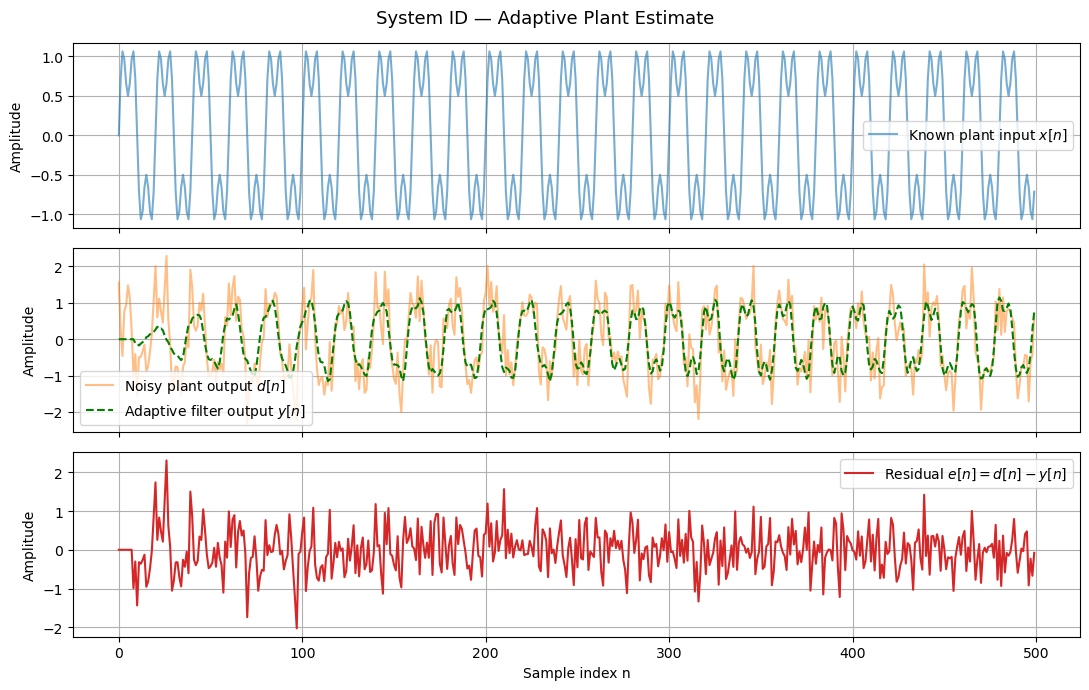

In [34]:
# System ID ->
M  = 8      # filter taps
mu = 0.02   # step size

y = np.zeros(N)
e = np.zeros(N)
w = np.zeros(M)

for i in range(M, N):
    x_vec = x[i - M + 1 : i + 1][::-1]  # [x[i], x[i-1], ..., x[i-M+1]]
    y[i] = np.dot(w, x_vec)
    e[i] = d[i] - y[i]
    w = w + mu * e[i] * x_vec

print(f"Learned weights: {np.round(w, 4)}")

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
fig.suptitle("System ID — Adaptive Plant Estimate", fontsize=13)

axes[0].plot(n, x, alpha=0.6, label="Known plant input $x[n]$")
axes[0].set_ylabel("Amplitude"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(n, d, label="Noisy plant output $d[n]$", lw=1.5, alpha=0.5,color="tab:orange")
axes[1].plot(n, y, label="Adaptive filter output $y[n]$", lw=1.5, color="green", linestyle="--")
axes[1].set_ylabel("Amplitude"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(n, e, label="Residual $e[n] = d[n] - y[n]$", color="tab:red")
axes[2].set_xlabel("Sample index n")
axes[2].set_ylabel("Amplitude"); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

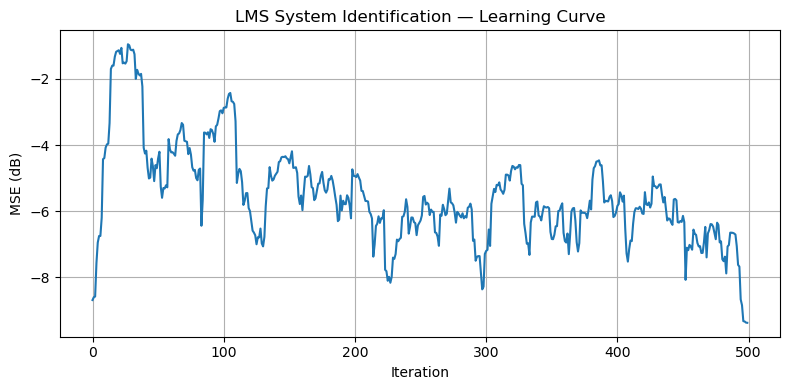

In [35]:
# Learning curve (MSE in dB)
mse = np.convolve(e**2, np.ones(25) / 25, mode="same")

plt.figure(figsize=(8, 4))
plt.plot(10 * np.log10(mse + 1e-12))
plt.title("LMS System Identification — Learning Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.grid(True)
plt.tight_layout()
plt.show()